# Electrical stimulation fMRI: stimulation response analysis

Continues on the output of `mol_fMRI_electric_stim_preprocessing.ipynb`. Pick the analysis folder of a finished preprocessing run (the folder with `session.json`, e.g. `.../stitched_36-31-40_functionalEPI/analysis`). Folders from older runs without `session.json` are reconstructed from the folder layout. Nothing is recomputed in the preprocessing, so this notebook can be started at any time.

1. Load the session.
2. Locate the stimulation scan and derive the epoch timing.
3. Register to the atlas and run the stimulation check on every atlas region.
4. Move the voxelwise stimulation maps to atlas space for group analysis.

In [1]:
import importlib
import electric_stim_helpers, electric_stim_session
importlib.reload(electric_stim_helpers)  # picks up edits of the helper modules without restarting the kernel
importlib.reload(electric_stim_session)
from electric_stim_helpers import *
from electric_stim_session import *

# Linux workstation mounts the data under /home, macOS under /Volumes
FMRI_ROOT = next(p for p in ("/home/pschmidt/fmri_analysis", "/Volumes/pschmidt/fmri_analysis") if os.path.isdir(p))

selected_session = FileChooser(f"{FMRI_ROOT}/AnalysedData", layout=widgets.Layout(width="1080px"))
selected_session.show_only_dirs = True
display(selected_session)

FileChooser(path='/Volumes/pschmidt/fmri_analysis/AnalysedData', filename='', title='', show_hidden=False, sel…

In [2]:
session, session_source = load_session(selected_session.selected_path)

in_path = session["in_path"]
subject_id = session["subject_id"]
func_scan_numbers = session["func_scan_numbers"]
struct_scan_number = session["struct_scan_number"]
analysed_func_dir = session["analysed_func_dir"]
analysed_struct_dir = session["analysed_struct_dir"]
analysis_dir = session["analysis_dir"]
mask_file = session["mask_file"]
structural_file_for_coregistration = session["structural_file_for_coregistration"]
scan_ranges = read_scan_ranges(analysed_func_dir)

os.chdir(analysis_dir)
require_files([analysed_func_dir / "mc_func.nii.gz", analysis_dir / "mean_mc_func.nii.gz", mask_file, structural_file_for_coregistration,
               analysed_func_dir / "scan_boundaries.csv"],
              "Run the preprocessing notebook up to the structural processing first.")

if session_source != str(analysis_dir / SESSION_FILE):
    save_session(analysis_dir, **session)  # next time this folder loads directly
print_statement(f"Session {session_source}", bcolors.NOTIFICATION)
print_statement(f"Subject {subject_id}, functional scans {', '.join(func_scan_numbers)} (stitched), structural scan {struct_scan_number}", bcolors.NOTIFICATION)
print_statement(f"Analysis folder: {analysis_dir}", bcolors.NOTIFICATION)
for scan, start, end in scan_ranges:
    print(f"  Scan {scan}: volumes {start}-{end}")

Session /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/session.json
Subject RGRO_260817_0224_SD_1363_3, functional scans 17, 20, 25 (stitched), structural scan 9
Analysis folder: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis
  Scan 1: volumes 0-299
  Scan 2: volumes 300-2099
  Scan 3: volumes 2100-3599


# Stimulation Setup

Locates the stimulation scan (the one with `FMRIYesNo=Yes` in its Bruker `method` file) in the stitched series and derives the epoch timing. The stimulation check itself is run on the mean time course of every atlas region in the atlas section below, so no manually drawn ROIs are needed.

Stimulation: 5 Hz pulses (200 ms interval, 100 µs width, 3 mA), 40 s ON / 20 s OFF per 60 s epoch. The epoch timing is read from the `method` file (`PreBaselineNum`, `StimNum` + `InterStimNum`, `NEpochs`); the ON/OFF split is set below because the `method` file only stores the 60 s period.

Percent signal change is relative to the pre-stimulation baseline at the start of the stimulation scan. A paired t-test across epochs compares the ON window (after the hemodynamic lag) with the rest period right before each onset.

In [3]:
from scipy import stats

STIM_ON_S = 40
STIM_OFF_S = 20
LAG_S = 5   # hemodynamic delay excluded from the start of the ON window
PRE_S = 10  # rest window before each onset used as the comparison

if not scan_ranges:
    raise RuntimeError("scan_boundaries.csv not found, cannot locate the stimulation scan in the stitched series.")

stim_idx = next((i for i, num in enumerate(func_scan_numbers)
                 if re.search(r"##\$FMRIYesNo=Yes", (Path(in_path) / num / "method").read_text())), None)
if stim_idx is None:
    raise ValueError(f"None of the scans {func_scan_numbers} has FMRIYesNo=Yes in its method file.")

stim_num = func_scan_numbers[stim_idx]
p_stim = func_param_extract(Path(in_path) / stim_num, export_env=False)
stim_tr = p_stim["VolTR"]
_, stim_start, stim_end = scan_ranges[stim_idx]
stim_end += 1  # exclusive

n_base_vols = p_stim["Baseline_TRs"]
period_vols = p_stim["StimOn_TRs"] + p_stim["StimOff_TRs"]
if abs(period_vols * stim_tr - (STIM_ON_S + STIM_OFF_S)) > 1e-6:
    print_statement(f"Epoch period in method file ({period_vols * stim_tr:.0f} s) differs from STIM_ON_S + STIM_OFF_S.", bcolors.FAIL)

on_vols = int(round(STIM_ON_S / stim_tr))
lag_vols = int(round(LAG_S / stim_tr))
pre_vols = int(round(PRE_S / stim_tr))
onsets = [stim_start + n_base_vols + k * period_vols for k in range(p_stim["NoOfEpochs"])]
onsets = [o for o in onsets if o + period_vols <= stim_end]

print_statement(f"Stimulation scan {stim_num} (volumes {stim_start}-{stim_end - 1}): {len(onsets)} epochs, "
                f"first onset at volume {onsets[0]}, period {period_vols * stim_tr:.0f} s", bcolors.NOTIFICATION)

Stimulation scan 20 (volumes 300-2099): 27 epochs, first onset at volume 480, period 60 s


# Atlas Coregistration and Stimulation Response per Brain Region

Select the species in the widget cell below; it fills in the matching atlas:
- **Rat:** SIGMA in vivo template, rigid registration.
- **Mouse:** DSURQE (MICe) template. It is an ex vivo, whole-head average, so it is brain-masked, downsampled to 0.1 mm for registration, and registered with a scaling term and `nmi` cost. Any other mouse template/label pair (e.g. Allen CCFv3) can be entered instead.

Follows `roi_atlas_analysis.py`: the structural scan is registered to the functional mean (struct2func, rigid) and to the atlas template (struct2atlas), and the two matrices are composed into one functional → atlas matrix. The multi-label atlas is resampled once onto the functional grid with nearest-neighbour interpolation, so the functional data itself is never interpolated. Outputs go to `roi_atlas_<species>/`.

Then the mean time course of every atlas region (inside the brain mask) is extracted and the stimulation check (paired t-test, ON window vs. preceding rest) is run on each region, with Benjamini-Hochberg FDR correction across regions. Requires the stimulation setup cell above to have been run. This replaces manually drawn ROIs. Outputs:
- `atlas_roi_stim_response.csv`: every region with ON/rest signal change, t, p and FDR-corrected q; `atlas_roi_responders.csv` lists only the regions with a significant positive response.
- `time_courses/time_course_roi_<id>_<name>.txt`: mean time course of every region.
- `stim_check_plots/`: one figure per region (full scan with stimulation periods and the epoch average ± SEM); the responders are also in `stim_check_plots/responders/`.
- The somatosensory (S1) regions are printed separately as a check that the stimulation worked.

Optional label names CSV: either columns `id,name`, or the DSURQE / SIGMA structure lists with separate left and right label columns (regions then get an `_L` / `_R` suffix). Without it, regions are named `label_<id>`.

In [4]:
ATLAS_ROOT = f"{FMRI_ROOT}/atlas"
SIGMA_DIR = (f"{ATLAS_ROOT}/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/"
             "SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1")
SIGMA_ATLAS_DIR = f"{SIGMA_DIR}/SIGMA_Rat_Brain_Atlases/SIGMA_Anatomical_Atlas/InVivo_Atlas"

# Rat: SIGMA in vivo. Mouse: DSURQE (40 µm, ex vivo T2w).
SPECIES_ATLAS = {
    "rat": {
        "template": f"{SIGMA_DIR}/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii",
        "labels": f"{SIGMA_ATLAS_DIR}/SIGMA_InVivo_Anatomical_Brain_Atlas.nii",
        "mask": "", "names": f"{SIGMA_ATLAS_DIR}/SIGMA_InVivo_Anatomical_Brain_Atlas_ListOfStructures.csv",
        "warp": "shift_rotate", "cost": "lpa+ZZ", "reg_voxel_mm": None,
    },
    "mouse": {
        "template": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/DSURQE_40micron_average.nii",
        "labels": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/DSURQE_40micron_labels.nii",
        "mask": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/DSURQE_40micron_mask.nii",
        "names": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/dsurqe_labels.csv",
        # Scaling absorbs the size difference between in vivo brains and the ex vivo template
        "warp": "shift_rotate_scale", "cost": "nmi", "reg_voxel_mm": 0.1,
    },
}

atlas_layout = widgets.Layout(width="700px")
atlas_style = {"description_width": "160px"}
species_dropdown = widgets.Dropdown(options=list(SPECIES_ATLAS), value="rat", description="Species:", layout=widgets.Layout(width="280px"), style=atlas_style)
atlas_template_entered = widgets.Text(description="Atlas template:", layout=atlas_layout, style=atlas_style)
atlas_labels_entered = widgets.Text(description="Atlas labels:", layout=atlas_layout, style=atlas_style)
atlas_mask_entered = widgets.Text(placeholder="optional, restricts the template to the brain", description="Template brain mask:", layout=atlas_layout, style=atlas_style)
atlas_names_entered = widgets.Text(placeholder="optional CSV (id,name or left/right label columns)", description="Label names CSV:", layout=atlas_layout, style=atlas_style)


def fill_atlas_defaults(change=None):
    cfg = SPECIES_ATLAS[species_dropdown.value]
    atlas_template_entered.value = cfg["template"]
    atlas_labels_entered.value = cfg["labels"]
    atlas_mask_entered.value = cfg["mask"]
    atlas_names_entered.value = cfg["names"]


species_dropdown.observe(fill_atlas_defaults, names="value")
fill_atlas_defaults()

display(widgets.VBox([species_dropdown, atlas_template_entered, atlas_labels_entered, atlas_mask_entered, atlas_names_entered],
    layout=widgets.Layout(padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")))

In [5]:
species = species_dropdown.value
species_cfg = SPECIES_ATLAS[species]
atlas_template = Path(atlas_template_entered.value.strip()).resolve()
atlas_labels = Path(atlas_labels_entered.value.strip()).resolve()
atlas_mask_text = atlas_mask_entered.value.strip()
for f in (atlas_template, atlas_labels) + ((Path(atlas_mask_text),) if atlas_mask_text else ()):
    if not f.is_file():
        raise FileNotFoundError(f"{f} (atlas files for {species} not found; check the paths above)")

atlas_dir = analysis_dir / f"roi_atlas_{species}"
atlas_dir.mkdir(exist_ok=True)
func_reference = analysis_dir / "mean_mc_func.nii.gz"
struct_for_atlas = Path(structural_file_for_coregistration)

# +xz suits a coronal slab with limited A-P coverage
STRUCT2FUNC_COST, STRUCT2FUNC_CMASS = "nmi", None
STRUCT2ATLAS_COST, STRUCT2ATLAS_CMASS = species_cfg["cost"], "+xz"


def run_afni(cmd, capture=False):
    cmd = [str(c) for c in cmd]
    print("[COMMAND]", " ".join(cmd))
    return subprocess.run(cmd, check=True, text=True, capture_output=capture)


def prepare_registration_template():
    """Brain-mask and/or downsample the template so registration is robust and fast."""
    template = atlas_template
    if atlas_mask_text:
        masked = atlas_dir / "template_masked.nii.gz"
        if not masked.exists():
            run_afni(["3dcalc", "-a", template, "-b", atlas_mask_text, "-expr", "a*step(b)", "-prefix", masked])
        template = masked
    if species_cfg["reg_voxel_mm"]:
        vox = species_cfg["reg_voxel_mm"]
        coarse = atlas_dir / f"template_registration_{vox}mm.nii.gz"
        if not coarse.exists():
            run_afni(["3dresample", "-dxyz", vox, vox, vox, "-rmode", "Cu", "-input", template, "-prefix", coarse])
        template = coarse
    return template


def register(source, base, prefix, cost, cmass, warp):
    matrix = atlas_dir / f"{prefix}.aff12.1D"
    aligned = atlas_dir / f"{prefix}_aligned.nii.gz"
    if matrix.exists() and aligned.exists():
        print_statement(f"{prefix} registration already exists. Skipping.", bcolors.OKGREEN)
        return matrix
    cmd = ["3dAllineate", "-source", source, "-base", base, "-prefix", aligned, "-1Dmatrix_save", matrix,
           "-1Dparam_save", atlas_dir / f"{prefix}_params.1D", "-warp", warp, "-cost", cost,
           "-source_automask+2", "-twopass", "-twobest", "MAX", "-float", "-verb", "-overwrite"]
    if cmass:
        cmd.append(f"-cmass{cmass}")
    run_afni(cmd)
    return matrix


def aff12_to_matvec(matrix, out):
    vals = [float(v) for line in Path(matrix).read_text().splitlines()
            if line.strip() and not line.lstrip().startswith("#") for v in line.split()]
    if len(vals) != 12:
        raise ValueError(f"Expected 12 values in {matrix}, found {len(vals)}.")
    Path(out).write_text("\n".join(" ".join(f"{v:.12g}" for v in vals[i:i + 4]) for i in (0, 4, 8)) + "\n")
    return out


print_header(f"Registering structural to functional and to the {species} atlas", bcolors.HEADER)
struct2func = register(struct_for_atlas, func_reference, "struct2func", STRUCT2FUNC_COST, STRUCT2FUNC_CMASS, "shift_rotate")
struct2atlas = register(struct_for_atlas, prepare_registration_template(), "struct2atlas", STRUCT2ATLAS_COST, STRUCT2ATLAS_CMASS, species_cfg["warp"])

# 3dAllineate matrices are base -> source; functional -> atlas = inverse(struct2atlas) after struct2func
composite = atlas_dir / "func_to_atlas_for_roi_apply.aff12.1D"
res = run_afni(["cat_matvec", "-ONELINE",
                aff12_to_matvec(struct2func, atlas_dir / "struct2func.matvec"),
                aff12_to_matvec(struct2atlas, atlas_dir / "struct2atlas.matvec"), "-I"], capture=True)
composite.write_text(res.stdout.strip() + "\n")

# Labels stay at full resolution; the matrix is in physical coordinates so the downsampled template doesn't matter here
labels_funcspace = atlas_dir / "atlas_labels_funcspace.nii.gz"
run_afni(["3dAllineate", "-source", atlas_labels, "-master", func_reference, "-1Dmatrix_apply", composite,
          "-final", "NN", "-prefix", labels_funcspace, "-overwrite"])
print_statement(f"[OK] Atlas labels in functional space: {labels_funcspace}", bcolors.OKGREEN)

# Check the registration visually before trusting the regions
subprocess.run(["fsleyes", str(func_reference), str(labels_funcspace), "-cm", "random", "-a", "40"])


**************************************************************************************************************************************
                                      Registering structural to functional and to the rat atlas                                       
**************************************************************************************************************************************

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/31anatomy/cleaned_struct.nii.gz -base /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/mean_mc_func.nii.gz -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/struct2func_aligned.nii.gz -1Dmatrix_save /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/31anatomy/cleaned_struct.nii.gz
++ Base dataset:   /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/mean_mc_func.nii.gz
++ Loading datasets into memory
++ 145355 voxels in -source_automask+2
++ Zero-pad: xbot=8 xtop=8
++ Zero-pad: ybot=8 ytop=8
++ Zero-pad: zbot=8 ztop=8
++ Computing -autobox
 + Weightize: xfade=7 yfade=4 zfade=7
 + Weightize: (unblurred) top clip=112818
 + Weightize: (blurred) bot clip=3353.88
 + Weightize: 63991 voxels survive clip
 + Weightize: 63945 voxels survive clusterize
 + Weightize: binarizing
 + Weightize: box=4..77 X 1..24 X 5..75 = 126096 voxels
++ -autobox net CPU time = 0.0 s
++ 127925 voxels [76.9%] in weight mask
++ Number of points for matching = 60124
++ base center of mass = 40.980 12.2

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/31anatomy/cleaned_struct.nii.gz -base /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/struct2atlas_aligned.nii.gz -1Dmatrix_save /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/struct2atlas.aff12.1D -1Dparam_save /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/struct2atlas_params.1D -warp shift_rotate -cost lpa+ZZ -source_automask+2 -twopass -twobes

++ lpa+ parameters: hel=0.40 mi=0.00 nmi=0.20 crA=0.40 ov=0.40 [to be zeroed at Final iteration]
++ Option '-cmass+xz' enables center-of-mass code = 5 = +xz
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/31anatomy/cleaned_struct.nii.gz
++ Base dataset:   /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii
*+ WARNING: Cost 'ls' or 'lpc' or 'lpa' ==> turning '-autoweight' on
          If you DO NOT want this to happen, then use one
          of '-autobox' or '-automask' or '-noauto'.
++ Loading datasets into memory
++ 145355 voxels in -source_automask+2
++ Zero-pad: xbot=19 xtop=18
++ Zero-pad: ybot=16 ytop=9
++ Zero-pad: zbot=10 ztop=0
++ Computing -autobox
 + Weightize: xfade=11 yfade=15 zfade=9
 + Weightize: (u

[COMMAND] cat_matvec -ONELINE /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/struct2func.matvec /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/struct2atlas.matvec -I
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Brain_Atlases/SIGMA_Anatomical_Atlas/InVivo_Atlas/SIGMA_InVivo_Anatomical_Brain_Atlas.nii -master /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/mean_mc_func.nii.gz -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/func_to_atlas_for_roi_apply.aff12.1D -final NN -prefix /Volumes

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Brain_Atlases/SIGMA_Anatomical_Atlas/InVivo_Atlas/SIGMA_InVivo_Anatomical_Brain_Atlas.nii
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    6.115   10.449    6.115
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_labels_funcspace.nii.gz
++ 3dAllineate: total CPU time = 0.1 sec  Elapsed = 0.4
++ ###########################################################


[OK] Atlas labels in functional space: /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_labels_funcspace.nii.gz


CompletedProcess(args=['fsleyes', '/Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/mean_mc_func.nii.gz', '/Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_labels_funcspace.nii.gz', '-cm', 'random', '-a', '40'], returncode=0)

76 regions analysed, 1 with significant positive response (FDR q < 0.05)
 label_id                                                      name  n_voxels    on_psc  rest_psc  diff_psc         t        p    q_fdr  responder
      521               Primary Somatosensory Cortex Barrel field_L        86  0.924421  0.670009  0.254412  4.073803 0.000386 0.029303       True
      731                                                Striatum_L       671 -0.688105 -0.632823 -0.055283 -2.606296 0.014951 0.412357      False
      611                  Primary Somatosensory Cortex Upperlips_L       156  0.629974  0.502347  0.127627  2.491543 0.019425 0.412357      False
      891 Corpus Callosum and Associated Subcortical White Matter_L       221 -0.633269 -0.574613 -0.058655 -2.379324 0.024970 0.412357      False
      101                                           Dentate Gyrus_L        12  0.080841  0.266371 -0.185530 -2.341760 0.027129 0.412357      False
      722                          Secondary 

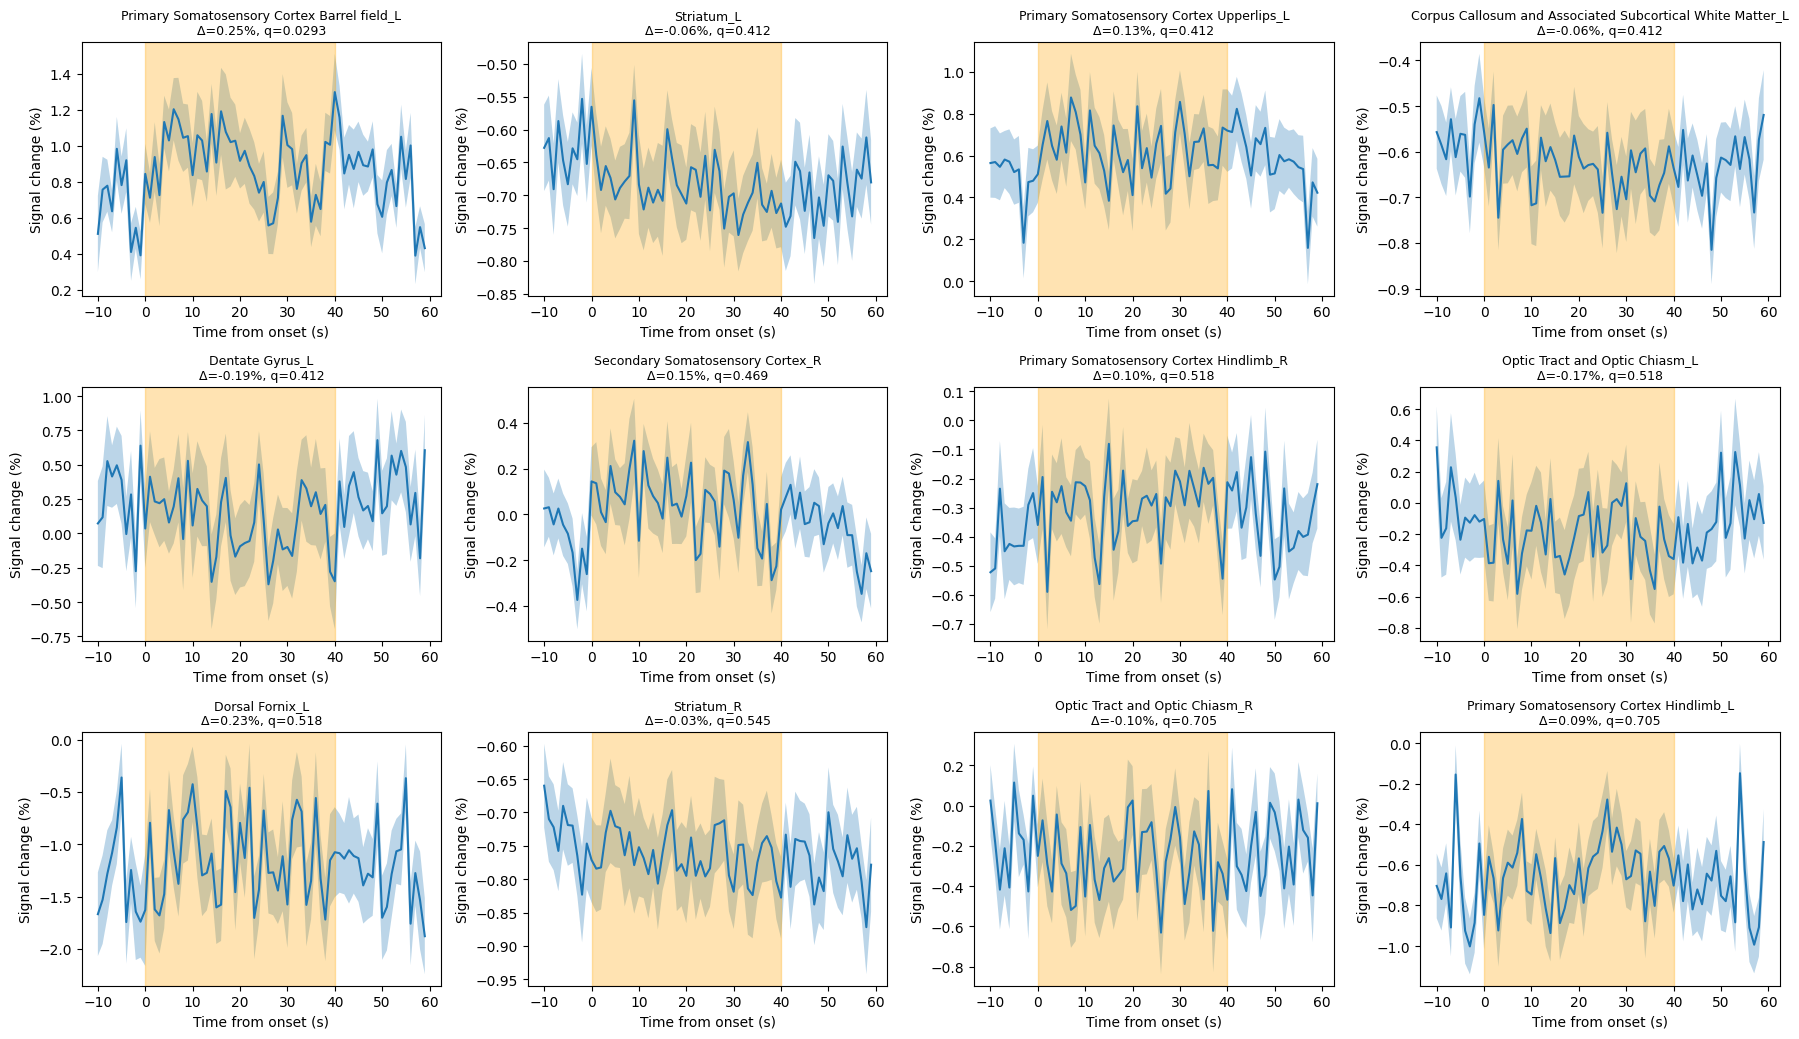

Stim-check figures saved in /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/stim_check_plots (1 responders in /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/stim_check_plots/responders)
Region time courses saved in /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/time_courses


In [6]:
from statsmodels.stats.multitest import multipletests

MIN_VOXELS = 5
FDR_ALPHA = 0.05
N_PLOT = 12
SAVE_ALL_REGION_PLOTS = True  # one stim-check figure per region in stim_check_plots/ (responders always saved)
S1_PATTERN = r"somatosens|\bS1"  # regions printed as the stimulation sanity check

labels_img = nib.load(str(labels_funcspace))
labels = np.rint(labels_img.get_fdata()).astype(int)
brain = nib.load(mask_file).get_fdata() > 0
if brain.shape != labels.shape:
    raise ValueError(f"Brain mask {brain.shape} and atlas labels {labels.shape} are on different grids.")
labels[~brain] = 0

func_4d = nib.load(str(analysed_func_dir / "mc_func.nii.gz")).get_fdata(dtype=np.float32)


def load_label_names(csv_path):
    """Accepts an id,name CSV or the DSURQE/SIGMA layouts with separate left and right label columns."""
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    if "id" in cols and "name" in cols:
        return {int(i): str(n) for i, n in zip(df[cols["id"]], df[cols["name"]])}
    left = next(c for k, c in cols.items() if "left" in k and "label" in k)
    right = next(c for k, c in cols.items() if "right" in k and "label" in k)
    name_col = next(c for k, c in cols.items() if k in ("structure", "region of interest"))
    names = {}
    for _, row in df.iterrows():
        for col, side in ((left, "L"), (right, "R")):
            if pd.notna(row[col]):
                names[int(row[col])] = f"{row[name_col]}_{side}"
    return names


label_names = load_label_names(atlas_names_entered.value.strip()) if atlas_names_entered.value.strip() else {}


def stim_response(ts):
    base = ts[stim_start:stim_start + n_base_vols].mean()
    psc = (ts - base) / base * 100
    epochs = np.array([psc[o - pre_vols:o + period_vols] for o in onsets])
    on = epochs[:, pre_vols + lag_vols:pre_vols + on_vols].mean(axis=1)
    rest = epochs[:, :pre_vols].mean(axis=1)
    t_stat, p_val = stats.ttest_rel(on, rest)
    return epochs, on.mean(), rest.mean(), t_stat, p_val


def safe_name(text):
    return re.sub(r"[^\w.\-]+", "_", str(text)).strip("_")


tc_dir = atlas_dir / "time_courses"
tc_dir.mkdir(exist_ok=True)
plot_dir = atlas_dir / "stim_check_plots"
plot_dir.mkdir(exist_ok=True)
(plot_dir / "responders").mkdir(exist_ok=True)

rows, region_ts, region_epochs = [], {}, {}
for lid in np.unique(labels[labels > 0]):
    sel = labels == lid
    n_vox = int(sel.sum())
    if n_vox < MIN_VOXELS:
        continue
    ts = func_4d[sel].mean(axis=0)
    if ts[stim_start:stim_start + n_base_vols].mean() <= 0:
        continue
    epochs, on_psc, rest_psc, t_stat, p_val = stim_response(ts)
    np.savetxt(tc_dir / f"time_course_roi_{lid}_{safe_name(label_names.get(int(lid), f'label_{lid}'))}.txt", ts)
    region_ts[lid] = ts
    region_epochs[lid] = epochs
    rows.append({"label_id": int(lid), "name": label_names.get(int(lid), f"label_{lid}"), "n_voxels": n_vox,
                 "on_psc": on_psc, "rest_psc": rest_psc, "diff_psc": on_psc - rest_psc, "t": t_stat, "p": p_val})

results = pd.DataFrame(rows)
valid = results["p"].notna()
results.loc[valid, "q_fdr"] = multipletests(results.loc[valid, "p"], alpha=FDR_ALPHA, method="fdr_bh")[1]
results = results.sort_values("p").reset_index(drop=True)
results["responder"] = (results["q_fdr"] < FDR_ALPHA) & (results["diff_psc"] > 0)

results.to_csv(atlas_dir / "atlas_roi_stim_response.csv", index=False)
results[results["responder"]].to_csv(atlas_dir / "atlas_roi_responders.csv", index=False)
pd.DataFrame({results.loc[results.label_id == lid, "name"].iloc[0]: ts for lid, ts in region_ts.items()}).to_csv(
    atlas_dir / "atlas_roi_timeseries_all.csv", index_label="timepoint")

print_statement(f"{len(results)} regions analysed, {int(results['responder'].sum())} with significant positive response (FDR q < {FDR_ALPHA})", bcolors.OKGREEN)
print(results.head(20).to_string(index=False))

s1 = results[results["name"].str.contains(S1_PATTERN, case=False, regex=True)]
print_statement("Somatosensory (S1) regions:" if len(s1) else "No region name matches S1_PATTERN (provide a label names CSV).", bcolors.NOTIFICATION)
if len(s1):
    print(s1.to_string(index=False))

# Map of the ON - rest signal change in regions that respond
response_map = np.zeros(labels.shape, dtype=np.float32)
for r in results[results["responder"]].itertuples():
    response_map[labels == r.label_id] = r.diff_psc
nib.save(nib.Nifti1Image(response_map, labels_img.affine, labels_img.header), str(atlas_dir / "atlas_roi_stim_response_map.nii.gz"))

# Epoch averages of the strongest regions
t_epoch = np.arange(-pre_vols, period_vols) * stim_tr
top = results.head(N_PLOT)
fig, axes = plt.subplots(int(np.ceil(len(top) / 4)), 4, figsize=(18, 3.5 * int(np.ceil(len(top) / 4))), squeeze=False)
for ax, r in zip(axes.flat, top.itertuples()):
    ep = region_epochs[r.label_id]
    m = ep.mean(axis=0)
    sem = ep.std(axis=0, ddof=1) / np.sqrt(len(ep))
    ax.plot(t_epoch, m)
    ax.fill_between(t_epoch, m - sem, m + sem, alpha=0.3)
    ax.axvspan(0, STIM_ON_S, color="orange", alpha=0.3)
    ax.set_title(f"{r.name}\nΔ={r.diff_psc:.2f}%, q={r.q_fdr:.3g}", fontsize=9)
    ax.set_xlabel("Time from onset (s)")
    ax.set_ylabel("Signal change (%)")
for ax in list(axes.flat)[len(top):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(atlas_dir / "atlas_roi_stim_response_top_regions.svg", dpi=300)
plt.show()


def save_region_plot(r):
    ts, ep = region_ts[r.label_id], region_epochs[r.label_id]
    base = ts[stim_start:stim_start + n_base_vols].mean()
    psc = (ts - base) / base * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot((np.arange(stim_start, stim_end) - stim_start) * stim_tr, psc[stim_start:stim_end], lw=0.8)
    for o in onsets:
        ax1.axvspan((o - stim_start) * stim_tr, (o - stim_start + on_vols) * stim_tr, color="orange", alpha=0.3)
    ax1.set_xlabel("Time in stimulation scan (s)")
    ax1.set_ylabel("Signal change (%)")
    ax1.set_title(f"{r.name} ({r.n_voxels} voxels): stimulation scan {stim_num} (orange = stimulation ON)")
    m = ep.mean(axis=0)
    sem = ep.std(axis=0, ddof=1) / np.sqrt(len(ep))
    ax2.plot(t_epoch, m)
    ax2.fill_between(t_epoch, m - sem, m + sem, alpha=0.3)
    ax2.axvspan(0, STIM_ON_S, color="orange", alpha=0.3)
    ax2.axvline(0, color="k", lw=0.5)
    ax2.set_xlabel("Time from stimulation onset (s)")
    ax2.set_ylabel("Signal change (%)")
    ax2.set_title(f"Epoch average ± SEM (n={len(ep)}), ON {r.on_psc:.2f}% vs rest {r.rest_psc:.2f}%, "
                  f"t={r.t:.2f}, p={r.p:.3g}, q={r.q_fdr:.3g}")
    fig.tight_layout()
    fname = f"stim_check_{r.label_id}_{safe_name(r.name)}.svg"
    if SAVE_ALL_REGION_PLOTS:
        fig.savefig(plot_dir / fname, dpi=300)
    if r.responder:
        fig.savefig(plot_dir / "responders" / fname, dpi=300)
    plt.close(fig)


for r in results.itertuples():
    if SAVE_ALL_REGION_PLOTS or r.responder:
        save_region_plot(r)
print_statement(f"Stim-check figures saved in {plot_dir} ({int(results['responder'].sum())} responders in {plot_dir / 'responders'})", bcolors.OKGREEN)
print_statement(f"Region time courses saved in {tc_dir}", bcolors.OKGREEN)

# Voxelwise Stimulation Maps in Atlas Space (for group analysis)

The region analysis above stays in native space, so the functional time series are never interpolated. For voxelwise group statistics, the maps are computed in native space and then moved to atlas space with the inverse of the functional → atlas matrix estimated above (struct2func and struct2atlas), in a single resampling step:
- `stim_diff_psc`: mean ON − rest signal change (%) per voxel.
- `stim_tstat`: paired t of ON vs. rest across epochs per voxel (n epochs − 1 degrees of freedom).
- `mean_func` and `brain_mask`, for overlays and for restricting the group statistics to the brain.

Outputs go to `roi_atlas_<species>/atlas_space/` on the registration template grid, which is the same for every animal of the species. Region-wise group comparisons can use `atlas_roi_stim_response.csv` directly, since the atlas labels already define the same regions in every animal.

In [8]:
# Voxelwise ON - rest maps in native space (same definition as the region analysis: ON window after the lag vs. the rest right before each onset)
base_img = func_4d[..., stim_start:stim_start + n_base_vols].mean(axis=-1)
valid_vox = brain & (base_img > 0)
diffs = []
for o in onsets:
    on = func_4d[..., o + lag_vols:o + on_vols].mean(axis=-1)
    rest = func_4d[..., o - pre_vols:o].mean(axis=-1)
    diffs.append(np.where(valid_vox, (on - rest) / np.where(valid_vox, base_img, 1) * 100, 0))
diffs = np.stack(diffs)
diff_map = diffs.mean(axis=0)
sd = diffs.std(axis=0, ddof=1)
t_map = np.where(sd > 0, diff_map / (sd / np.sqrt(len(onsets)) + (sd == 0)), 0)
t_map[~valid_vox] = 0

native_maps = atlas_dir / "native_maps"
native_maps.mkdir(exist_ok=True)
mask_img = nib.load(mask_file)
for name, data in (("stim_diff_psc", diff_map), ("stim_tstat", t_map)):
    nib.save(nib.Nifti1Image(data.astype(np.float32), labels_img.affine, labels_img.header), str(native_maps / f"{name}.nii.gz"))

# Native -> atlas: inverse of the functional -> atlas matrix, resampled once onto the registration template grid
atlas_space = atlas_dir / "atlas_space"
atlas_space.mkdir(exist_ok=True)
atlas_grid = prepare_registration_template()
native_to_atlas = atlas_dir / "native_to_atlas.aff12.1D"
res = run_afni(["cat_matvec", "-ONELINE", composite, "-I"], capture=True)
native_to_atlas.write_text(res.stdout.strip() + "\n")

for name, source, interp in (("stim_diff_psc", native_maps / "stim_diff_psc.nii.gz", "linear"),
                             ("stim_tstat", native_maps / "stim_tstat.nii.gz", "linear"),
                             ("mean_func", func_reference, "linear"),
                             ("brain_mask", mask_file, "NN")):
    run_afni(["3dAllineate", "-source", source, "-master", atlas_grid, "-1Dmatrix_apply", native_to_atlas,
              "-final", interp, "-prefix", atlas_space / f"{name}_atlasspace.nii.gz", "-overwrite"])
print_statement(f"[OK] Maps in atlas space: {atlas_space}", bcolors.OKGREEN)

# Check the alignment of the warped maps on the template
subprocess.run(["fsleyes", str(atlas_grid), str(atlas_space / "stim_tstat_atlasspace.nii.gz"), "-cm", "hot", "-dr", "2", "6"])

[COMMAND] cat_matvec -ONELINE /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/func_to_atlas_for_roi_apply.aff12.1D -I
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_maps/stim_diff_psc.nii.gz -master /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_to_atlas.aff12.1D -final linear -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
** AFNI converts NIFTI_datatype=4 (INT16) in file /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_maps/stim_diff_psc.nii.gz to FLOAT32
     Warnings of this type will be muted for this session.
     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_maps/stim_diff_psc.nii.gz
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    7.584    1.445    7.584
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_maps/stim_tstat.nii.gz -master /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_to_atlas.aff12.1D -final linear -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_space/stim_tstat_atlasspace.nii.gz -overwrite
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/mean_mc_func.nii.gz
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    7.584    1.445    7.584
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_space/mean_func_atlasspace.nii.gz
++ 3dAllineate: total CPU time = 0.1 sec  Elapsed = 0.2
++ ###########################################################
++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/Ana

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/mask_mean_mc_func.nii.gz -master /Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/native_to_atlas.aff12.1D -final NN -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_space/brain_mask_atlasspace.nii.gz -overwrite
[OK] Maps in atlas space: /Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_space


CompletedProcess(args=['fsleyes', '/Volumes/pschmidt/fmri_analysis/atlas/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii', '/Volumes/pschmidt/fmri_analysis/AnalysedData/Sero/RGRO_260902_0224_RN_SD_463/stitched_33-34-36_functionalEPI/analysis/roi_atlas_rat/atlas_space/stim_tstat_atlasspace.nii.gz', '-cm', 'hot', '-dr', '2', '6'], returncode=0)